In [ ]:
#original stucture would fail since signs are too similar
#size is 6*3 per frame


In [ ]:
!conda install -c conda-forge matplotlib -y


In [ ]:
!conda install -c conda-forge opencv -y


In [ ]:
!pip install mediapipe

In [ ]:
!pip install scikit-learn

In [ ]:
!pip install tensorflow 

In [97]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [99]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [101]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
def draw_styled_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
def extract_keypoints(reference, results):
    global ref, lh
    if results.left_hand_landmarks:
        hand = results.left_hand_landmarks.landmark
        print(reference)
        if np.array_equal(reference, [0, 0, 0]):
            move_dist = [0,0,0]
        else:
            move_dist = [hand[0].x - reference[0], hand[0].y - reference[1], hand[0].z - reference[2]]
        ref = [hand[0].x, hand[0].y, hand[0].z]
        thumb_dist = [hand[4].x - hand[0].x, hand[4].y - hand[0].y, hand[4].z - hand[0].z]
        index_dist = [hand[8].x - hand[0].x, hand[8].y - hand[0].y, hand[8].z - hand[0].z]
        middle_dist = [hand[12].x - hand[0].x, hand[12].y - hand[0].y, hand[12].z - hand[0].z]
        ring_dist = [hand[16].x - hand[0].x, hand[16].y - hand[0].y, hand[16].z - hand[0].z]
        pinky_dist = [hand[20].x - hand[0].x, hand[20].y - hand[0].y, hand[20].z - hand[0].z]
        lh = np.array(move_dist + thumb_dist + index_dist + middle_dist + ring_dist + pinky_dist).flatten()
    else:
        lh =  np.zeros(6*3)
        ref = reference
    return ref, lh

In [103]:
print(os.getcwd())


C:\Users\seal\Desktop\projects\contactless_medical_image_system\training


In [57]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('vids') 

# Actions that we try to detect
actions = np.array(['1_up', '1_down', '1_left', '1_right', '2_up', '2_down', '3_up', '3_down', '3_left', '3_right', '4_up', '4_down', '5_up', '5_down', '5_left', '5_right', '6_up', '6_down', '6_left', '6_right'])

# Thirty videos worth of data
no_sequences = 100

# Videos are going to be 30 frames in length
sequence_length = 5

In [19]:
#creating directory for vids
for action in actions: 
    for sequence in range(1,no_sequences+1):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [35]:
for sequence in range(1,11):
        try: 
            os.makedirs(os.path.join(DATA_PATH, "test", str(sequence)))
        except:
            pass

In [39]:
#testing cv2
cap = cv2.VideoCapture(0)

# Check if the webcam is opened correctly
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Loop to capture and display the video in real-time
while True:
    # Capture a frame from the webcam
    ret, frame = cap.read()

    # Check if the frame is successfully captured
    if not ret:
        print("Failed to capture frame.")
        break

    # Display the frame in a window
    cv2.imshow('OpenCV Feed', frame)

    # Wait for the 'q' key to be pressed for exiting
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture object and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()

In [95]:
selected_action = '6_down'  # Change to the desired action
cap = cv2.VideoCapture(0)
# Initialize the Holistic model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    # Loop through sequences aka videos for the selected action
    for sequence in range(no_sequences):
        lh =  np.zeros(6*3)
        ref = [0,0,0]
        if sequence % 5 == 0:
            ret, frame = cap.read()
            image, results = mediapipe_detection(frame, holistic)
            cv2.putText(image, 'INTERMISSION', (120, 200), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
            cv2.imshow('OpenCV Feed', image)
            cv2.waitKey(1000)
        # Loop through video length aka sequence length (frames per video)
        for frame_num in range(sequence_length):

            # Read a frame from the webcam
            ret, frame = cap.read()

            # Make detections using MediaPipe Holistic
            image, results = mediapipe_detection(frame, holistic)

            # Draw landmarks on the frame
            draw_styled_landmarks(image, results)

            # Add text to the frame for visualization
            if frame_num == 0: 
                cv2.putText(image, 'STARTING COLLECTION', (120, 200), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                cv2.putText(image, f'Collecting frames for {selected_action} Video Number {sequence+1}', (15, 12), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
                cv2.waitKey(1)
            else: 
                cv2.putText(image, f'Collecting frames for {selected_action} Video Number {sequence+1}', (15, 12), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)

            # Export the keypoints for the current frame
            ref, keypoints = extract_keypoints(ref, results)
            npy_path = os.path.join(DATA_PATH, selected_action, str(sequence+1), str(frame_num))
            np.save(npy_path, keypoints)  

            # Exit gracefully if 'q' is pressed
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

# Release the capture and close OpenCV windows
cap.release()
cv2.destroyAllWindows()

[0, 0, 0]
[0.5759662389755249, 0.3508628308773041, -4.987547868040565e-07]
[0.5715668201446533, 0.36973103880882263, -4.27677434799989e-07]
[0.573492705821991, 0.37892624735832214, -4.611350163941097e-07]
[0.5760947465896606, 0.38949644565582275, -4.409998837218154e-07]
[0, 0, 0]
[0.5926652550697327, 0.4452435076236725, -4.888493663202098e-07]
[0.5984730124473572, 0.4615040719509125, -4.928547241433989e-07]
[0.6006217002868652, 0.47353145480155945, -4.611665929132869e-07]
[0.6109623312950134, 0.5240828394889832, -5.6302525308638e-07]
[0, 0, 0]
[0.6195148229598999, 0.5579171180725098, -5.010248855796817e-07]
[0.6226067543029785, 0.5725746154785156, -4.869905296800425e-07]
[0.6302284002304077, 0.6199296712875366, -5.391242439145572e-07]
[0.6332190632820129, 0.6321005821228027, -4.4174475988256745e-07]
[0, 0, 0]
[0.6342818140983582, 0.6556272506713867, -4.2948167333634046e-07]
[0.6364635825157166, 0.7015966773033142, -5.133818490321573e-07]
[0.6386411786079407, 0.71444171667099, -4.339347

In [67]:
temp1 = np.load("C:/Users/seal/Desktop/projects/contactless_medical_image_system/training/vids/test/1/0.npy")
temp2 = np.load("C:/Users/seal/Desktop/projects/contactless_medical_image_system/training/vids/test/1/1.npy")
temp3 = np.load("C:/Users/seal/Desktop/projects/contactless_medical_image_system/training/vids/test/1/2.npy")
temp4 = np.load("C:/Users/seal/Desktop/projects/contactless_medical_image_system/training/vids/test/1/3.npy")
temp5 = np.load("C:/Users/seal/Desktop/projects/contactless_medical_image_system/training/vids/test/1/4.npy")
print(temp1)
print(temp2)
print(temp3)
print(temp4)
print(temp5)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/seal/Desktop/projects/contactless_medical_image_system/training/vids/test/1/0.npy'

In [105]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [107]:
label_map = {label:num for num, label in enumerate(actions)}
label_map

{'1_up': 0,
 '1_down': 1,
 '1_left': 2,
 '1_right': 3,
 '2_up': 4,
 '2_down': 5,
 '3_up': 6,
 '3_down': 7,
 '3_left': 8,
 '3_right': 9,
 '4_up': 10,
 '4_down': 11,
 '5_up': 12,
 '5_down': 13,
 '5_left': 14,
 '5_right': 15,
 '6_up': 16,
 '6_down': 17,
 '6_left': 18,
 '6_right': 19}

In [109]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [110]:
np.array(sequences).shape

(2000, 5, 18)

In [111]:
np.array(labels).shape

(2000,)

In [112]:
X = np.array(sequences)
y = to_categorical(labels).astype(int)

In [113]:
X.shape

(2000, 5, 18)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [118]:
y_train

array([[0, 0, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [123]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [125]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [127]:
model = Sequential()
model.add(Input(shape=(5,18)))
model.add(LSTM(64, return_sequences=True, activation='relu'))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [129]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])


In [131]:
model.fit(X_train, y_train, epochs=500, callbacks=[tb_callback])


Epoch 1/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - categorical_accuracy: 0.0438 - loss: 2.9957
Epoch 2/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.0750 - loss: 2.8421
Epoch 3/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.1977 - loss: 2.1444
Epoch 4/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.2773 - loss: 1.7809
Epoch 5/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - categorical_accuracy: 0.3689 - loss: 1.5563
Epoch 6/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.3782 - loss: 1.4951
Epoch 7/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.4242 - loss: 1.3727
Epoch 8/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.4914 - loss: 1.2491
Epoch 9/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.5622 - loss: 1.1117
Epoch 10/500
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - categorical_accuracy: 0.5762 - loss: 1.0308
Epoch 11/500
60/60 ━━━━━━━━━━

In [103]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 128)         │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           660 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,118 (2.02 MB)

 Trainable params: 176,372 (688.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 352,746 (1.35 MB)

In [139]:
model.save('model.h5')

In [141]:
model.save('my_model.keras')

In [21]:
model.load_weights('model.h5')

NameError: name 'model' is not defined

In [133]:
from scipy import stats

In [135]:
colors = [(245,117,16), (117,245,16), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [137]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5
ref = [0,0,0]
lh = np.zeros(6*3)
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        ref, keypoints = extract_keypoints(ref, results)
        sequence.append(keypoints)
        sequence = sequence[-5:]
        
        if len(sequence) == 5:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            predictions.append(np.argmax(res))
            
            
        #3. Viz logic
            if np.unique(predictions[-10:])[0]==np.argmax(res): 
                if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
[0, 0, 0]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
[0.546183705329895, 1.1077396869659424, -5.940761980127718e-07]
<class 'mediapipe.python.solution_base.SolutionOutputs'>
[0.5721286535263062, 1.0945366621017456, -4.151736163748865e-07]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
6_left
<class 'mediapipe.python.solution_base.SolutionOutputs'>
[0.5693249106407166, 1.0860451459884644, -3.8482207287415804e-07]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6_left
<class 'mediapipe.python.solution_base.SolutionOutputs'>
[0.5624922513961792, 1.0799306631088257, -3.615134289702837e-07]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6_left
<class 'mediapipe.python.solution_base.SolutionOutputs'>
[0.5724959373474121, 1.0756791830062866, -3.477440486676642e-07]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6_left
<class 'mediapipe.python.sol

In [159]:
from sklearn.metrics import confusion_matrix, accuracy_score


In [161]:
yhat = model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [163]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [165]:
confusion_matrix(ytrue, yhat)

array([[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0,

In [247]:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(50, 50))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=100)
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=30)  # Adjust color bar font size

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45, fontsize=50)
        plt.yticks(tick_marks, target_names, fontsize=50)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center", fontsize = 30,
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label', fontsize=100)
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass),  fontsize=100)
    plt.savefig("confusion_matrix.png")
    plt.show()


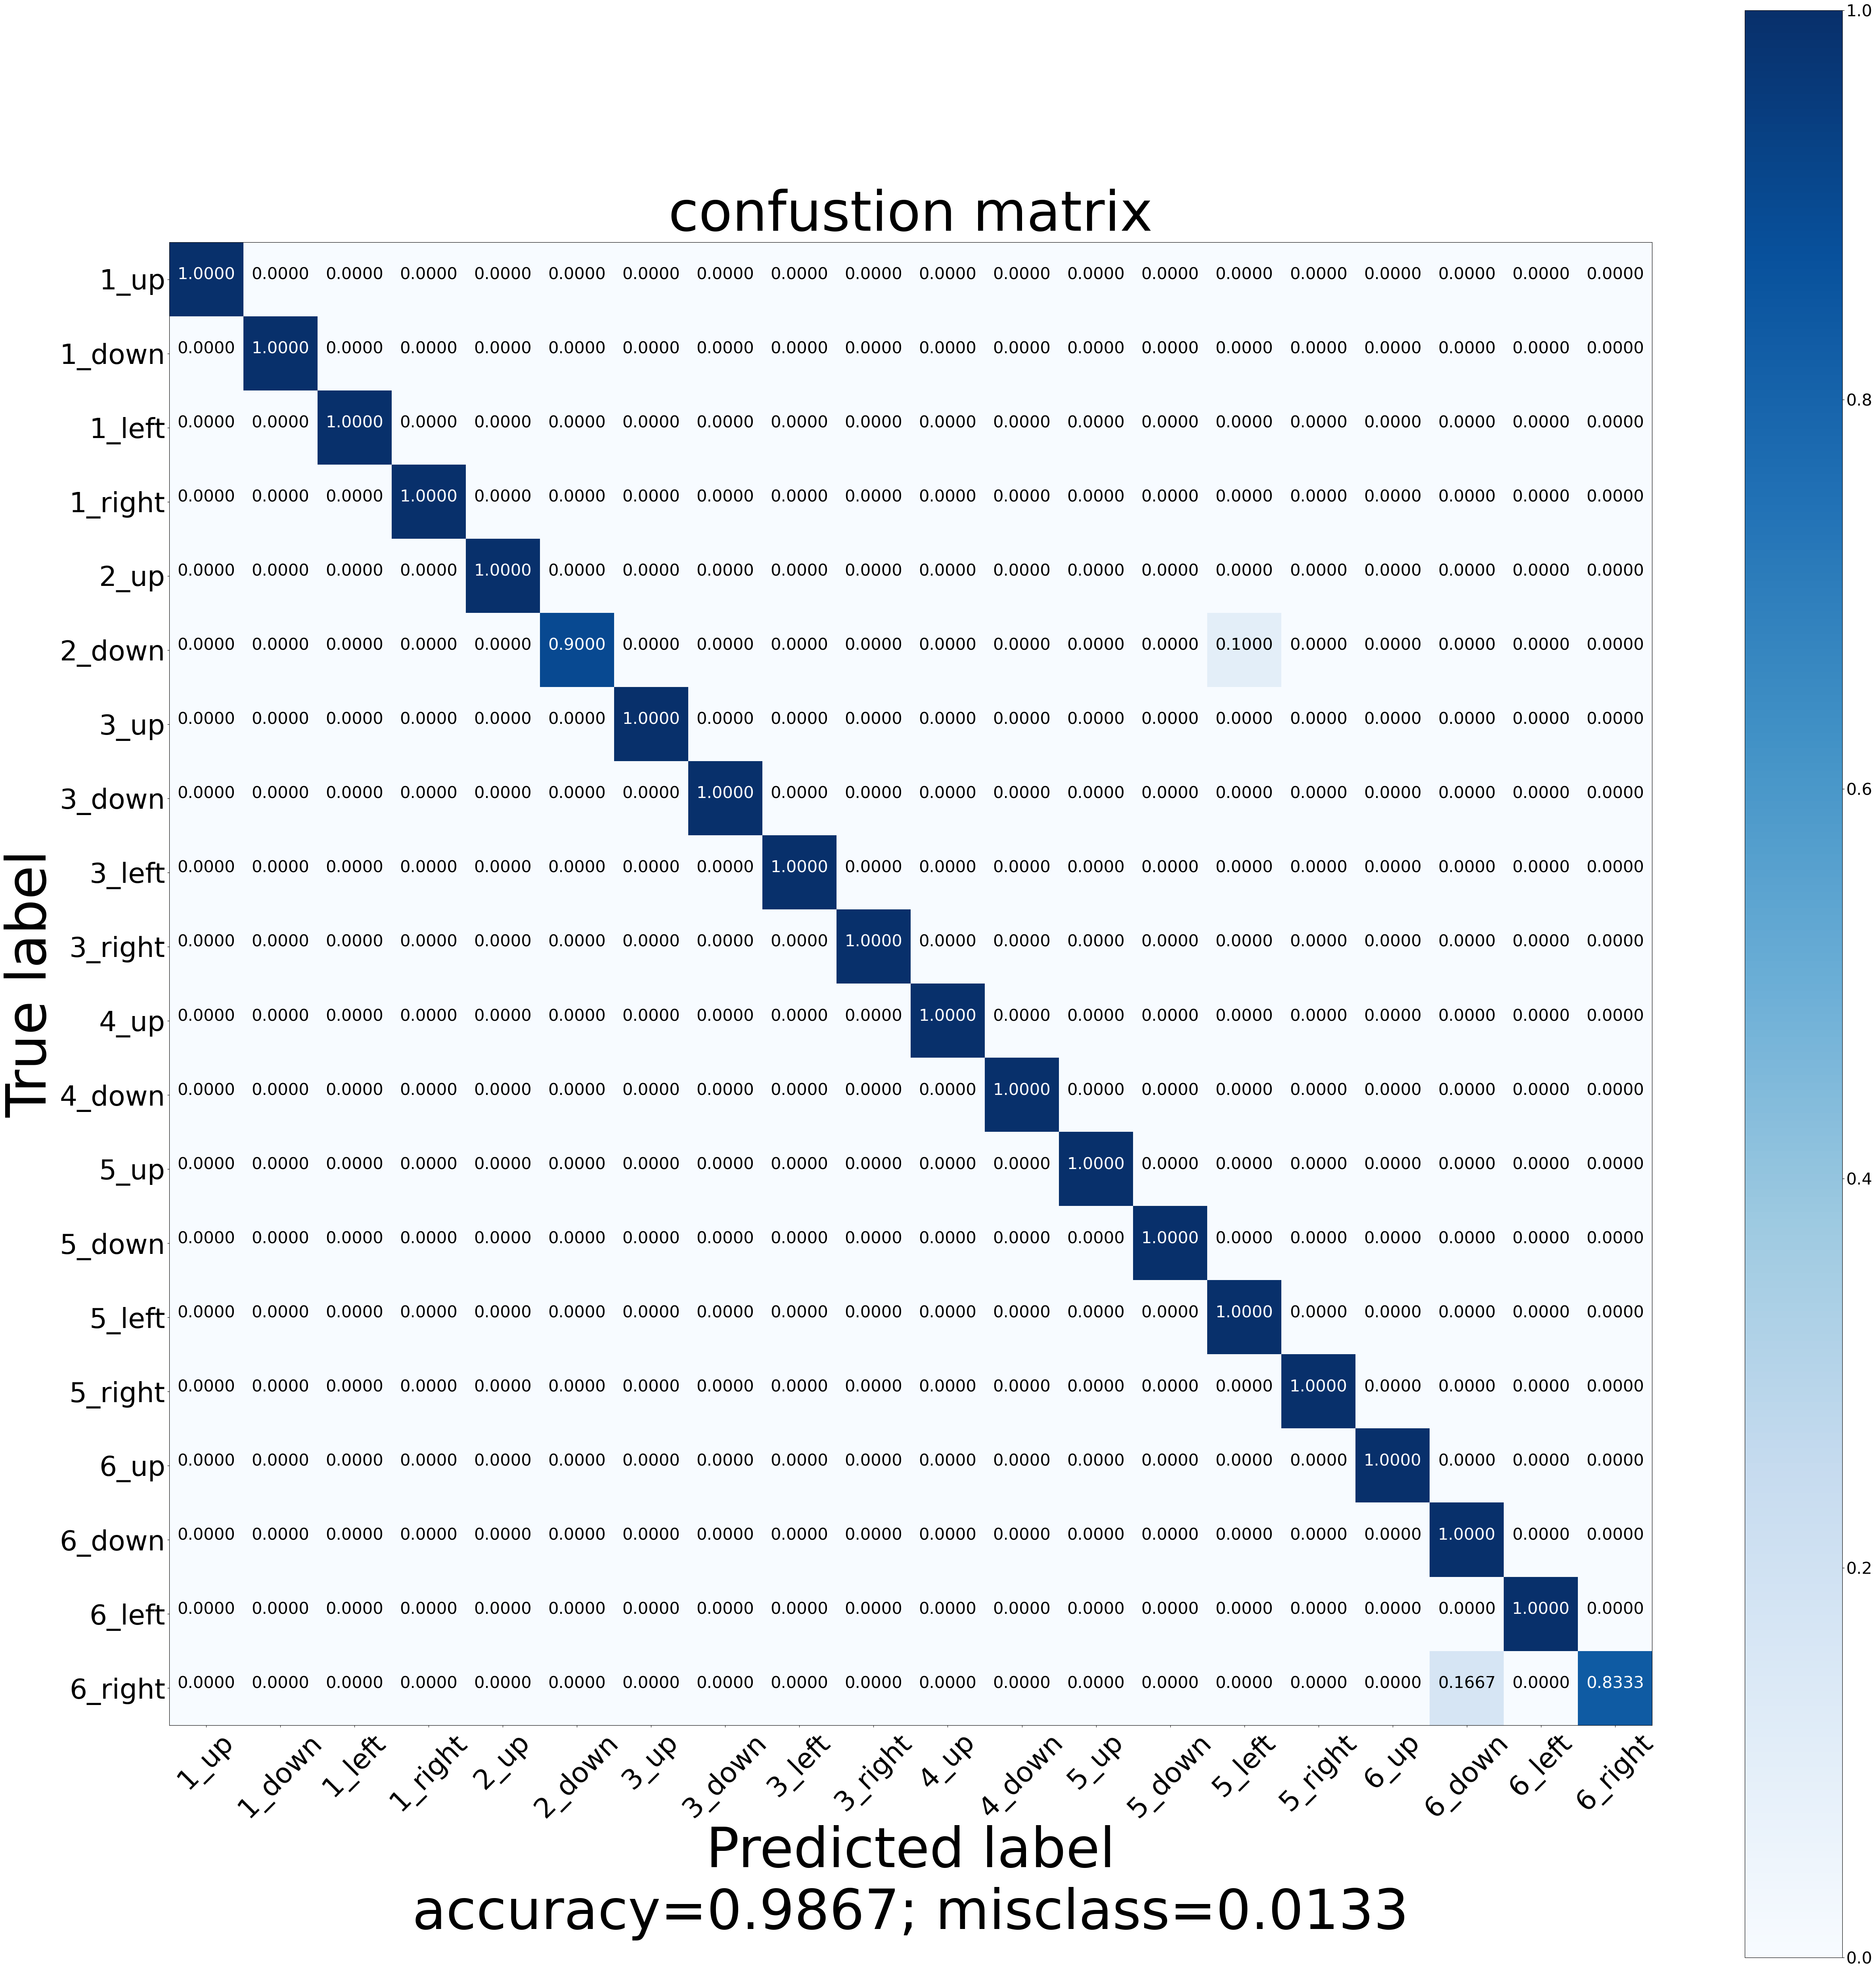

In [249]:
plot_confusion_matrix(confusion_matrix(ytrue, yhat).astype('float') / confusion_matrix(ytrue, yhat).sum(axis=1)[:, np.newaxis],
                     ['1_up', '1_down', '1_left', '1_right', '2_up', '2_down', '3_up', '3_down', '3_left', '3_right', '4_up', '4_down', '5_up', '5_down', '5_left', '5_right', '6_up', '6_down', '6_left', '6_right'],
                     "confustion matrix")